<a href="https://colab.research.google.com/github/Panos1992/Intro_to_python_2025/blob/main/Battery_SOH_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics

from scipy.interpolate import interp1d


In [146]:
import os
from google.colab import drive

# Mount Google Drive (this mounts the current user's Drive)
drive.mount('/content/drive')

# Path to the data
desired_path = '/content/drive/MyDrive/Battery data'

# Check if the folder exists, otherwise fallback to local Colab storage
if os.path.exists(desired_path):
    os.chdir(desired_path)
    print("Successfully connected to your shared Battery data folder!")
else:
    os.chdir('/content')
    print("Target Drive folder not found. Operating from local Colab directory instead.")

print("Current Working Directory: ", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully connected to your shared Battery data folder!
Current Working Directory:  /content/drive/MyDrive/Battery data


# Load Data and Clean

In [147]:
#df = pd.read_excel('999021.xls')
#df = pd.read_excel('Hybrid_PV_plus_storage_Cyprus.xlsx')
df = pd.read_csv('Solar-plus-storage_Cyprus_P1.csv', sep=';')
#df = pd.read_csv('Solar-plus-storage_Cyprus_P2.csv', sep=';') # not many full cycles
#df = pd.read_csv('Solar-plus-storage_Cyprus_P3.csv', sep=';')
#df = pd.read_csv('Solar-plus-storage_Cyprus_P4.csv', sep=';', encoding='latin1')  # crap data

### CPT data
#df = pd.read_csv('CPT_Battery_data_202505_202602.csv', sep=';').dropna()
#df = df[:53964]  # Keep only the first 6 months

#df['Time'] = pd.to_datetime(df['Time'])
#raw_df['Start'] = pd.to_datetime(raw_df['Start'])


# Convert 'Timestamp' to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M', errors='coerce') # Updated format for dayfirst dates, using errors='coerce' to handle invalid dates


df.info()
df.tail()  # This will print the first 5 rows of the DataFrame


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66958 entries, 0 to 66957
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Timestamp                     66958 non-null  datetime64[ns]
 1   Power production (W)          66958 non-null  int64         
 2   Power storage charge (W)      66958 non-null  int64         
 3   Power storage discharge (W)   66958 non-null  float64       
 4   Power grid import (W)         66958 non-null  int64         
 5   Power grid export (W)         66958 non-null  int64         
 6   Load consumption (W)          66958 non-null  int64         
 7   Battery state of charge (%)   66958 non-null  float64       
 8   Grid voltage (V)              0 non-null      float64       
 9   Battery voltage (V)           0 non-null      float64       
 10  Battery current (A)           0 non-null      float64       
 11  PV reactive power (VAr)     

,Timestamp,Power production (W),Power storage charge (W),Power storage discharge (W),Power grid import (W),Power grid export (W),Load consumption (W),Battery state of charge (%),Grid voltage (V),Battery voltage (V),Battery current (A),PV reactive power (VAr),Storage reactive power (VAr),Grid reactive power (VAr),Direct PV consumption (W)
66953,2019-12-31 23:00:00,0,0,0.0,748,0,748,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
66954,2019-12-31 23:15:00,0,0,0.0,701,0,701,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
66955,2019-12-31 23:30:00,0,0,0.0,814,0,814,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
66956,2019-12-31 23:45:00,0,0,0.0,898,0,898,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
66957,2020-01-01 00:00:00,0,0,0.0,997,0,997,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0


In [5]:

# Removing any commas and converting the columns to numeric
df['Power storage charge (W)'] = pd.to_numeric(df['Power storage charge (W)'].astype(str).str.replace(',', ''), errors='coerce')
df['Power storage discharge (W)'] = pd.to_numeric(df['Power storage discharge (W)'].astype(str).str.replace(',', ''), errors='coerce')


### Add some useful columns
df['Net Power W'] = df['Power storage charge (W)'] - df['Power storage discharge (W)']


df['Time_diff_hours'] = df['Timestamp'].diff().dt.total_seconds() / 3600  # Time difference in hours
df['Time_diff_hours'].fillna(0.25, inplace=True)  # Fill the first NaN with 0.25

### Remove some columns. Specify the columns you want to remove
#columns_to_remove = ['PV system Power production (W)','Direct PV consumption (W)', 'Power grid import (W)', 'Power grid export (W)', 'Load consumption (W)']
columns_to_remove = ['Power production (W)','Direct PV consumption (W)', 'Power grid import (W)', 'Power grid export (W)', 'Load consumption (W)','Grid voltage (V)', 'Battery voltage (V)', 'Battery current (A)', 'PV reactive power (VAr)', 'Storage reactive power (VAr)', 'Grid reactive power (VAr)']
df = df.drop(columns=columns_to_remove)

new_column_names = {
    'Power storage charge (W)': 'Charge_W',
    'Power storage discharge (W)': 'Discharge_W',
    'Battery state of charge (%)': 'SOC_%',
}

# SOC estimation from inverter: Voltage-based measurement
# SOC_% = (battery voltage - (low DC cutoff setting voltage + 0.2V) * 10%.

# Rename the columns
df = df.rename(columns=new_column_names)
# Print the updated DataFrame to verify
df.head()

/tmp/ipykernel_913/3150074875.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time_diff_hours'].fillna(0.25, inplace=True)  # Fill the first NaN with 0.25


,Timestamp,Charge_W,Discharge_W,SOC_%,Net Power W,Time_diff_hours
0,2018-02-02 12:45:00,2107,0.0,25.00,2107.0,0.25
1,2018-02-02 13:00:00,1944,0.0,29.00,1944.0,0.25
2,2018-02-02 13:15:00,1573,0.0,34.67,1573.0,0.25
3,2018-02-02 13:30:00,1907,0.0,39.00,1907.0,0.25
4,2018-02-02 13:45:00,1900,0.0,45.00,1900.0,0.25


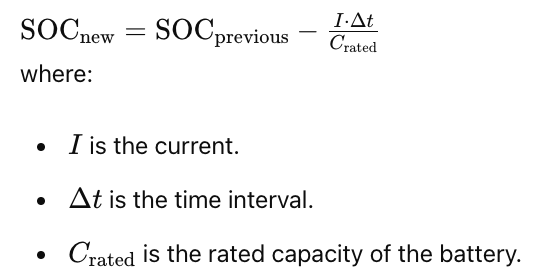![image.png]()

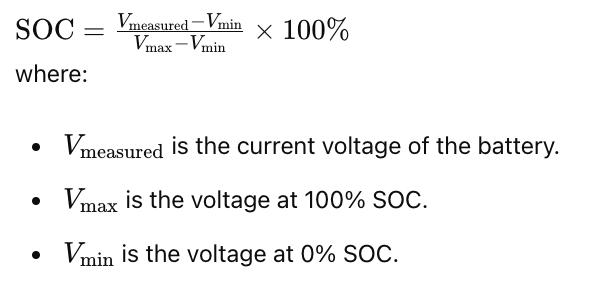

In [ ]:
df.tail()

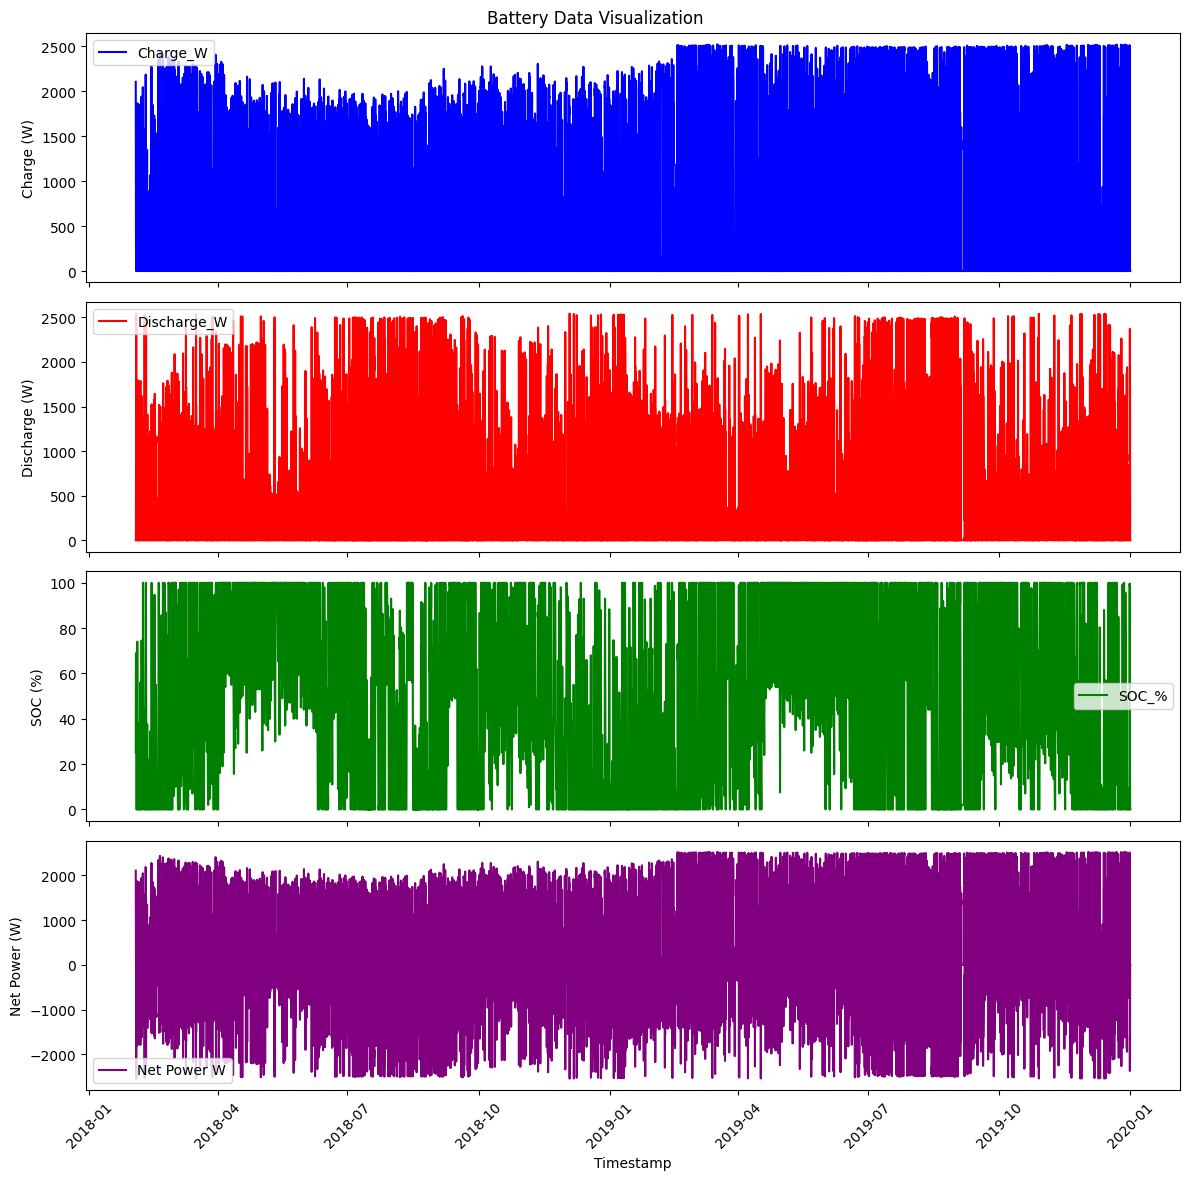

In [6]:
import matplotlib.pyplot as plt

# Create subplots for better visualization
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)  # 4 rows, 1 column

# Plot Charge_W
axes[0].plot(df['Timestamp'], df['Charge_W'], label='Charge_W', color='blue')
axes[0].set_ylabel('Charge (W)')
axes[0].legend()

# Plot Discharge_W
axes[1].plot(df['Timestamp'], df['Discharge_W'], label='Discharge_W', color='red')
axes[1].set_ylabel('Discharge (W)')
axes[1].legend()

# Plot SOC_%
axes[2].plot(df['Timestamp'], df['SOC_%'], label='SOC_%', color='green')
axes[2].set_ylabel('SOC (%)')
axes[2].legend()

# Plot Net Power W
axes[3].plot(df['Timestamp'], df['Net Power W'], label='Net Power W', color='purple')
axes[3].set_ylabel('Net Power (W)')
axes[3].legend()

# Set x-axis label and title
plt.xlabel('Timestamp')
plt.suptitle('Battery Data Visualization')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust spacing between subplots
plt.tight_layout()

# Display the plot
plt.show()

# Estimating Cycles, Energy & Capacity at each cycle
Cycle counting v1.0

In [133]:
# 'Power storage charge (W)' for charging power
# 'Power storage discharge (W)' for discharging power

# Initialize variables
df['Cycle'] = 0  # Create a new 'Cycle' column and initialize to 0
cycle_number = 0  # Start with cycle number 1
current_state = None  # Track the current state (charging or discharging)
charging_observed = False  # Flag to track if charging has been observed in the cycle
discharging_observed = False  # Flag to track if discharging has been observed in the cycle

# We can get initial capacity from the datasheet
Bat_capacity_initial = 9800; #kWh
#Bat_capacity_initial = 100000;

C_threshold = Bat_capacity_initial * 0.025 * 1 ; # A threshold to assume state change
#C_threshold = Bat_capacity_initial * 0.05 * 1 ;
print('Threshold [W]',C_threshold)

# Iterate through the DataFrame to assign cycle numbers
for index, row in df.iterrows():
    # Determine the current state based on power flow
    if row['Net Power W'] > C_threshold and row['SOC_%'] < 10:
        state = 'charging'
        charging_observed = True  # Set charging flag to True

    elif row['Net Power W'] < -C_threshold and row['SOC_%'] > 80:
        state = 'discharging'
        discharging_observed = True  # Set discharging flag to True
    else:
        state = current_state  # If neither charging nor discharging, maintain previous state

    # Check for state change to increment cycle number
    if current_state is None:  # First row
        current_state = state
    elif state != current_state:
        # Increment cycle number only if both charging and discharging have been observed
        if charging_observed and discharging_observed:
            cycle_number += 1
            charging_observed = False  # Reset flags for the new cycle
            discharging_observed = False
        current_state = state


    # Assign cycle number to the row
    df.loc[index, 'Cycle'] = cycle_number

# Now you have a 'Cycle' column in your DataFrame
print( 'Number of cycles', int(max(df['Cycle'])  ))


Threshold [W] 245.0
Number of cycles 594


### Cycle counting v2.0

In [9]:
# 'Power storage charge (W)' for charging power
# 'Power storage discharge (W)' for discharging power


# We can get it from the datasheet
Bat_capacity_initial = 9800;
#Bat_capacity_initial = 100000;

C_threshold = Bat_capacity_initial * 0.05 * 2 ; # 500W is a threshold to assume state change
print(C_threshold)

# Initialize variables
df['Cycle'] = 0  # Create a new 'Cycle' column and initialize to 0
cycle_number = 0  # Start with cycle number 1
current_state = None
charging_observed = False
discharging_observed = False

for index, row in df.iterrows():
    # 1. Determine State with a Buffer (Hysteresis)
    if row['Net Power W'] > C_threshold and row['SOC_%'] < 15:
        state = 'charging'
        charging_observed = True
    elif row['Net Power W'] < -C_threshold and row['SOC_%'] > 85:
        state = 'discharging'
        discharging_observed = True
    else:
        # Crucial: Don't change state if in the "deadzone"
        state = current_state

    # 2. Cycle Increment Logic
    if current_state is not None and state != current_state:
        # Only increment when completing a full round (e.g., switching BACK to charging)
        if charging_observed and discharging_observed and state == 'charging':
            cycle_number += 1
            # Reset flags only AFTER a full cycle is counted
            charging_observed = True # We are currently charging, so set to True
            discharging_observed = False

    current_state = state
    df.at[index, 'Cycle'] = cycle_number

# Now you have a 'Cycle' column in your DataFrame
print( max(df['Cycle']) )


980.0
237


In [ ]:
df.tail()

,Timestamp,SOC_%,Net Power W,Charge_W,Discharge_W,Time_diff_hours,Cycle
53959,2025-11-30 23:40:00,5,107,107,0,0.083333,176
53960,2025-11-30 23:45:00,5,138,138,0,0.083333,176
53961,2025-11-30 23:50:00,5,89,89,0,0.083333,176
53962,2025-11-30 23:55:00,5,144,144,0,0.083333,176
53963,2025-12-01 00:00:00,5,138,138,0,0.083333,176


In [ ]:
#df.head(50)
df[350:].head(50)

,Timestamp,SOC_%,Net Power W,Charge_W,Discharge_W,Time_diff_hours,Cycle
350,2025-05-20 05:10:00,5,79,79,0,0.083333,0
351,2025-05-20 05:15:00,5,63,63,0,0.083333,0
352,2025-05-20 05:20:00,5,67,67,0,0.083333,0
353,2025-05-20 05:25:00,5,100,100,0,0.083333,0
354,2025-05-20 05:30:00,5,59,59,0,0.083333,0
355,2025-05-20 05:35:00,5,71,71,0,0.083333,0
356,2025-05-20 05:40:00,5,88,88,0,0.083333,0
357,2025-05-20 05:45:00,5,94,94,0,0.083333,0
358,2025-05-20 05:50:00,5,42,42,0,0.083333,0
359,2025-05-20 05:55:00,5,73,73,0,0.083333,0


## Estimate Energy

In [134]:
first_cycle_df = df[df['Cycle'] == 1]
first_cycle_df['Energy'] = (first_cycle_df['Net Power W'] * first_cycle_df['Time_diff_hours']).astype(float)
total_energy_first_cycle = first_cycle_df['Energy'].sum().item()
print(f"Total energy for the first cycle: {total_energy_first_cycle} Wh")



Total energy for the first cycle: -7322.5 Wh


/tmp/ipykernel_913/910818444.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_cycle_df['Energy'] = (first_cycle_df['Net Power W'] * first_cycle_df['Time_diff_hours']).astype(float)


In [119]:
'''
# Find the Initial capacity of the battery, from the 1st cycle.
Energy_Wh = [];

for i in range(76,103):
  # Reset cumulative sum for each cycle
  # Calculate the energy for the current index i
  energy_i = (df['Net Power W'][i] * df['Time_diff_hours'][i]).item() # .item() converts numpy value to native python value
  # Append the calculated energy to the Energy_Wh list
  Energy_Wh.append(energy_i)

# Estimate the initial capacity from the first cycle
# We can get it from the datasheet
Bat_capacity_initial = sum(Energy_Wh)/df['SOC_%'][102]*100  # when SOC is 100%

'''



"\n# Find the Initial capacity of the battery, from the 1st cycle.\nEnergy_Wh = [];\n\nfor i in range(76,103):\n  # Reset cumulative sum for each cycle\n  # Calculate the energy for the current index i\n  energy_i = (df['Net Power W'][i] * df['Time_diff_hours'][i]).item() # .item() converts numpy value to native python value\n  # Append the calculated energy to the Energy_Wh list\n  Energy_Wh.append(energy_i)\n\n# Estimate the initial capacity from the first cycle\n# We can get it from the datasheet\nBat_capacity_initial = sum(Energy_Wh)/df['SOC_%'][102]*100  # when SOC is 100%\n\n"

In [135]:
#### Calculate the Energy transfer every timeframe
# The net energy transfered at each 15mins from or to the battery!
df['Energy_Wh']  = df['Net Power W'] * df['Time_diff_hours'];

# The Battery Capacity is the Cumulative Sum of the Net Energy.
df['Bat_Capacity'] = [float('nan')] * len(df) # Initialize 'Bat_Capacity' with NaN for all rows
df.loc[0, 'Bat_Capacity'] = Bat_capacity_initial*df.loc[0, 'Time_diff_hours']  + df.loc[0, 'Energy_Wh'];

eff_ch = 0.999 ;  # initial charge efficiencies. This can degrade in time
eff_dis = 0.999 ;
dod = 0.95;       # Depth of discharge

###### Estimate Battery Capacity in each timeframe
for i in range(1, len(df)):
    # Compare cycle numbers from the DataFrame column
    #if df.loc[i, 'Cycle'] > df.loc[i - 1, 'Cycle']:
    #    # Reset cumulative energy for a new cycle
    #   df.loc[i:, 'Bat_Capacity'] = 0  # Reset from current index onwards
    #    energy_i = 0;

    if df.loc[i, 'Net Power W'] > 0:
        # If the Net is positive, Accumulate energy in the 'Bat_Capacity' column
        #eff_ch = eff_ch* 0.9999997 # Assuming degradation 2% per year
        df.loc[i, 'Bat_Capacity'] = df.loc[i - 1, 'Bat_Capacity'] + df.loc[i, 'Energy_Wh']*eff_ch
    else:
        # If the Net is negative, Remove energy in the 'Bat_Capacity' column
        #eff_dis = eff_dis* 1.0000002986   # Assuming degradation 2% per year
        df.loc[i, 'Bat_Capacity'] = df.loc[i - 1, 'Bat_Capacity'] + df.loc[i, 'Energy_Wh']*eff_dis

    #df.loc[i, 'Bat_Capacity'] = df.loc[i - 1, 'Bat_Capacity'] + df.loc[i, 'Energy_Wh']

    #### Need to put Limits on the Maximum and Minimum Battery Capacity
    # THe capacity cannot be higher than Initial, and cannot be less than 0

    if df.loc[i, 'SOC_%'] == 0:
        #df.loc[i, 'Bat_Capacity'] = 0;
        df.loc[i, 'Bat_Capacity'] = (1-dod) * Bat_capacity_initial;  # assuming dod 90%

    if df.loc[i, 'SOC_%'] == 100:
        df.loc[i, 'Bat_Capacity'] = df.loc[i - 1, 'Bat_Capacity'];
        #df.loc[i, 'Bat_Capacity'] = Bat_capacity_initial;

    if df.loc[i, 'Bat_Capacity'] > Bat_capacity_initial:  # Maximum Capacity is the initial
        df.loc[i, 'Bat_Capacity'] = Bat_capacity_initial;

    #if df.loc[i, 'Bat_Capacity'] < 0:
        #df.loc[i, 'Bat_Capacity'] = 0;
    if df.loc[i, 'Bat_Capacity'] < (1-dod)* Bat_capacity_initial:  # assuming dod 90%
        df.loc[i, 'Bat_Capacity'] = (1-dod)* Bat_capacity_initial;

# Print the updated DataFrame
print(df)


                Timestamp  Charge_W  Discharge_W  SOC_%  Net Power W  \
0     2018-02-02 12:45:00      2107          0.0  25.00       2107.0   
1     2018-02-02 13:00:00      1944          0.0  29.00       1944.0   
2     2018-02-02 13:15:00      1573          0.0  34.67       1573.0   
3     2018-02-02 13:30:00      1907          0.0  39.00       1907.0   
4     2018-02-02 13:45:00      1900          0.0  45.00       1900.0   
...                   ...       ...          ...    ...          ...   
66953 2019-12-31 23:00:00         0          0.0   0.00          0.0   
66954 2019-12-31 23:15:00         0          0.0   0.00          0.0   
66955 2019-12-31 23:30:00         0          0.0   0.00          0.0   
66956 2019-12-31 23:45:00         0          0.0   0.00          0.0   
66957 2020-01-01 00:00:00         0          0.0   0.00          0.0   

       Time_diff_hours  Cycle  Energy_Wh  Bat_Capacity  Estimated_SOC  
0                 0.25      0     526.75    2976.75000      30.

In [ ]:
df[270:].tail()

,Timestamp,SOC_%,Net Power W,Charge_W,Discharge_W,Time_diff_hours,Cycle,Energy_Wh,Bat_Capacity,Estimated_SOC
53959,2025-11-30 23:40:00,5,107,107,0,0.083333,297,8.916667,10269.237609,10.269238
53960,2025-11-30 23:45:00,5,138,138,0,0.083333,297,11.500000,10280.726109,10.280726
53961,2025-11-30 23:50:00,5,89,89,0,0.083333,297,7.416667,10288.135359,10.288135
53962,2025-11-30 23:55:00,5,144,144,0,0.083333,297,12.000000,10300.123359,10.300123
53963,2025-12-01 00:00:00,5,138,138,0,0.083333,297,11.500000,10311.611859,10.311612


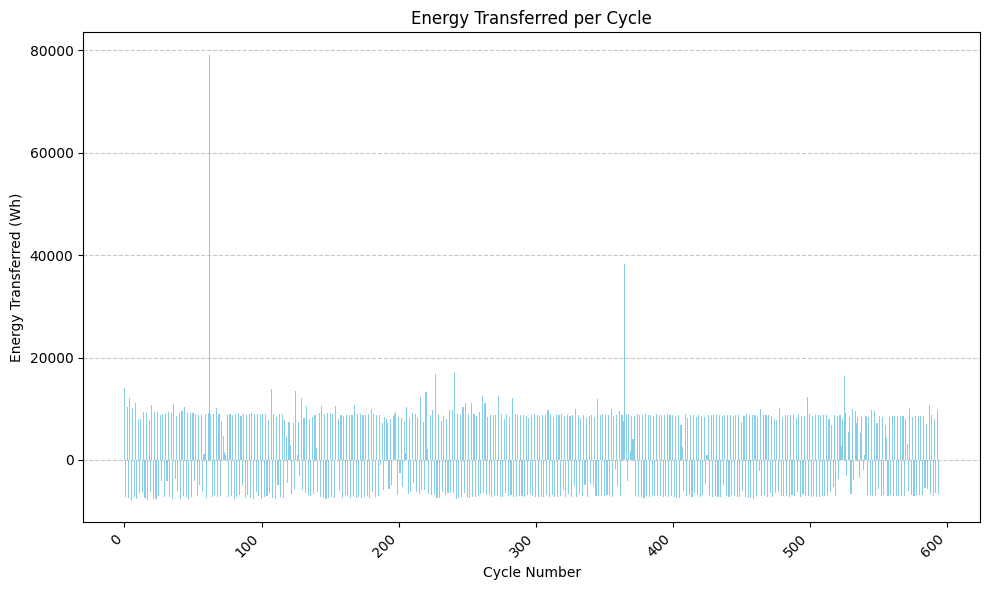

In [136]:
import matplotlib.pyplot as plt
import numpy as np

cycle_energy = df.groupby('Cycle')['Energy_Wh'].sum()

# Create the bar chart
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.bar(cycle_energy.index, cycle_energy.values, color='skyblue')

# Set labels and title
plt.xlabel('Cycle Number')
plt.ylabel('Energy Transferred (Wh)')
plt.title('Energy Transferred per Cycle')

# Customize the plot (optional)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines

# Display the plot
plt.tight_layout()
plt.show()

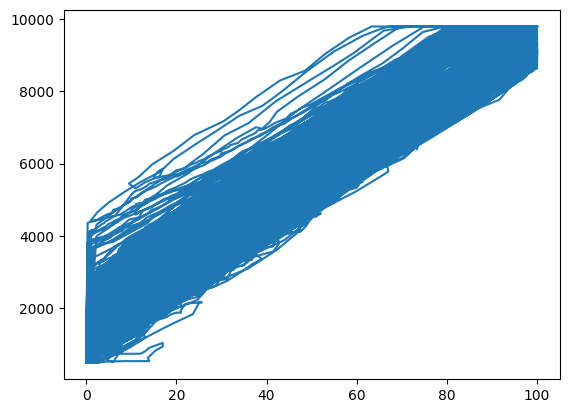

In [104]:
plt.plot(df['SOC_%'], df['Bat_Capacity'])

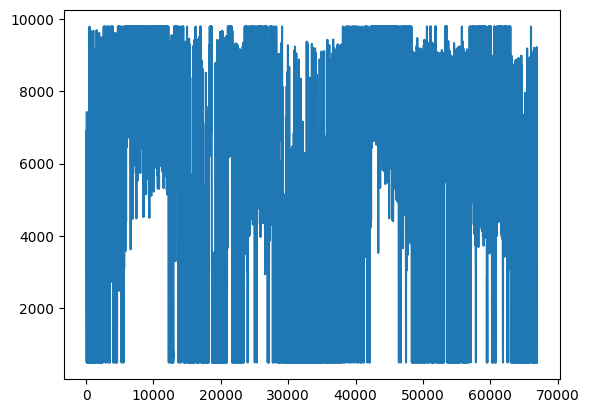

In [105]:
#plt.plot(df['SOC_%'])
#plt.plot( df['Bat_Capacity'][0:3000])
plt.plot( df['Bat_Capacity'])


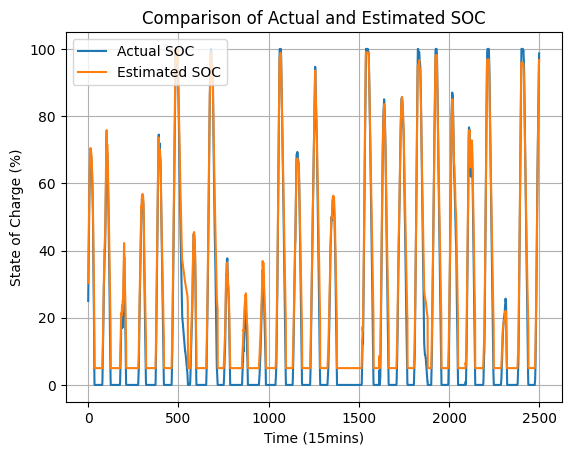

In [137]:
df['Estimated_SOC'] = 100*df['Bat_Capacity'] / Bat_capacity_initial

#plt.figure(figsize=(8, 4))
plt.plot(df['SOC_%'][:2500], label='Actual SOC')
plt.plot(df['Estimated_SOC'][:2500], label='Estimated SOC')
plt.title('Comparison of Actual and Estimated SOC')  # Add a title
plt.xlabel('Time (15mins)')  # Add x-axis label
plt.ylabel('State of Charge (%)')  # Add y-axis label
plt.legend()  # Display the legend to identify lines
plt.grid(True)  # Optionally add a grid for better readability
plt.show()

In [138]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score

mae = mean_absolute_error(df['SOC_%'], df['Estimated_SOC'])
mape = mean_absolute_percentage_error(df['SOC_%'], df['Estimated_SOC'])
rmse = np.sqrt(mean_squared_error(df['SOC_%'], df['Estimated_SOC']))
nrmse = rmse / np.max(df['Estimated_SOC']);

print(f'mae: {round(mae,2)}')
print(f'mape: {100*round(mape,4)} %')
print(f'rmse: {round(rmse,2)}')
print(f'nrmse: {100*round(nrmse,4)} %')

mae: 7.35
mape: 4.742843688939795e+17 %
rmse: 10.02
nrmse: 10.02 %


# Estimate SOH based on FUlly charged Cycles

In [139]:
# Filter data for cycles where SOC reaches 100%

filtered_df = df[df['SOC_%'] >= 99]  # Filter for SOC values greater than or equal to 95
#filtered_df = df[df['SOC_%'] >= 80]  #
#filtered_df = df[df['Estimated_SOC'] >= 95]  # Filter for SOC values greater than or equal to 95

# Group filtered data by cycle and calculate max capacity
grouped_filtered_df = filtered_df.groupby('Cycle')
max_cap_by_cycle = grouped_filtered_df['Bat_Capacity'].max()

# Estimate SOH
estimated_soh = max_cap_by_cycle / Bat_capacity_initial * 100
estimated_soh = estimated_soh.reset_index()

estimated_soh['Bat_Capacity'] = np.clip(estimated_soh['Bat_Capacity'], None, 100)

# Print or use the result
print('length of 100% cycles:', int(len(estimated_soh) ))
estimated_soh.head()

length of 100% cycles: 366


,Cycle,Bat_Capacity
0,0,99.892258
1,2,98.732704
2,4,98.793867
3,8,98.977357
4,14,96.670992


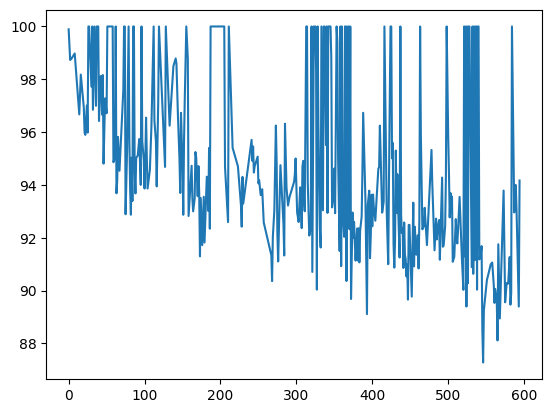

In [140]:
plt.plot(estimated_soh['Cycle'],estimated_soh['Bat_Capacity'])

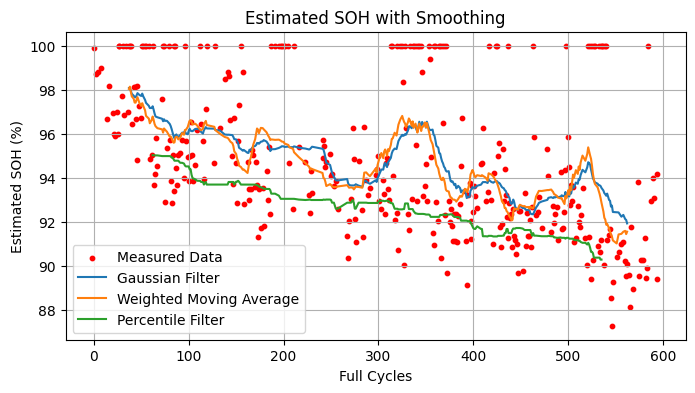

In [141]:
from scipy.signal import savgol_filter

# Define the window size for the moving average
window_size = int(len(estimated_soh)/10)  # You can adjust this value
# Create weights for the WMA (e.g., linearly decreasing weights)
weights = np.arange(1, window_size + 1)

# Calculate the moving average using a rolling window
estimated_soh_ma = estimated_soh['Bat_Capacity'].rolling(window=window_size, center=True).mean()
estimated_soh_gaussian = estimated_soh['Bat_Capacity'].rolling(window=window_size, win_type='gaussian', center=True).mean(std=window_size/0.5)
estimated_soh_wma = estimated_soh['Bat_Capacity'].rolling(window=window_size, win_type=None, center=True).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
estimated_soh_median = estimated_soh['Bat_Capacity'].rolling(window=window_size, center=True).median()

def percentile_filter(data, window_size, percentile):
    return data.rolling(window=window_size, center=True).quantile(percentile/100)


#estimated_soh_percentile = percentile_filter(estimated_soh['Bat_Capacity'], 66, 25)
estimated_soh_percentile = percentile_filter(estimated_soh['Bat_Capacity'], 2*window_size, 25)

def hampel_filter(data, window_size, n_sigmas=3):
    rolling_median = data.rolling(window=window_size, center=True).median()
    rolling_mad = data.rolling(window=window_size, center=True).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)  # MAD
    threshold = n_sigmas * rolling_mad
    filtered_data = np.where(np.abs(data - rolling_median) > threshold, rolling_median, data)
    return pd.Series(filtered_data, index=data.index)
estimated_soh_hampel = hampel_filter(estimated_soh['Bat_Capacity'], window_size)

# Convert your column to a numpy array
capacity_array = estimated_soh['Bat_Capacity'].to_numpy()
# Apply Savitzky–Golay filter
#estimated_soh_sg = savgol_filter(capacity_array, window_length=55, polyorder=2)

plt.figure(figsize=(8, 4))

#plt.plot(estimated_soh['Cycle'],estimated_soh['Bat_Capacity'], label='Measured Data')
plt.scatter(estimated_soh['Cycle'],estimated_soh['Bat_Capacity'], label='Measured Data', color='red', s=10)

#plt.plot(estimated_soh['Cycle'],estimated_soh_ma, label='Moving Average')
plt.plot(estimated_soh['Cycle'],estimated_soh_gaussian, label='Gaussian Filter')
plt.plot(estimated_soh['Cycle'],estimated_soh_wma, label='Weighted Moving Average')
#plt.plot(estimated_soh['Cycle'],estimated_soh_sg, label='Shavitzky-Golay')
#plt.plot(estimated_soh['Cycle'],estimated_soh_median, label='median Filter')
plt.plot(estimated_soh['Cycle'],estimated_soh_percentile, label='Percentile Filter')
#plt.plot(estimated_soh['Cycle'],estimated_soh_hampel, label='hampel Filter')

plt.title('Estimated SOH with Smoothing')  # Add a title
plt.xlabel('Full Cycles')  # Add x-axis label
plt.ylabel('Estimated SOH (%)')  # Add y-axis label
plt.legend()  # Display the legend to identify lines
plt.grid(True)  # Optionally add a grid for better readability

plt.show()

In [142]:
# Drop N/A values
estimated_soh_ma  = estimated_soh_ma.dropna() ### Since it is MA, drop the NaN values
estimated_soh_gaussian  = estimated_soh_gaussian.dropna()
estimated_soh_wma  = estimated_soh_wma.dropna()
estimated_soh_percentile  = estimated_soh_percentile.dropna()
estimated_soh_hampel  = estimated_soh_hampel.dropna()

# Create a new DataFrame with aligned Cycle and Bat_Capacity columns
estimated_soh_filtered  = pd.DataFrame({'Cycle': estimated_soh['Cycle'][estimated_soh_percentile.index],
                                  'Bat_Capacity': estimated_soh_percentile.values})

#estimated_soh_filtered  = pd.DataFrame({'Cycle': estimated_soh['Cycle'][estimated_soh_ma.index],
#                                  'Bat_Capacity': estimated_soh_ma.values})


In [128]:
estimated_soh_filtered.head()

,Cycle,Bat_Capacity
30,55,95.026592
31,56,95.026592
32,57,95.026592
33,58,95.026592
34,61,95.026592


# Model fitting and future SOh estimation

In [143]:
# Get the x-values (e.g., cycle numbers or time)
#x_values = estimated_soh_ma.index.values  # If 'estimated_soh_ma' is a Pandas Series
x_values = estimated_soh_filtered['Cycle']
#x_values = estimated_soh_filtered['Cycle'] // 2  ## check the cycles are not double!

# Get the y-values (estimated SOH values)
y_values = estimated_soh_filtered['Bat_Capacity']

# Get training data and test data
split_point = int((len(estimated_soh_filtered) * 0.80))
# Sequentially split the datasets
X_train, X_test = x_values[:split_point], x_values[split_point:]  # Choose inputs unscaled
y_train, y_test = y_values[:split_point], y_values[split_point:]


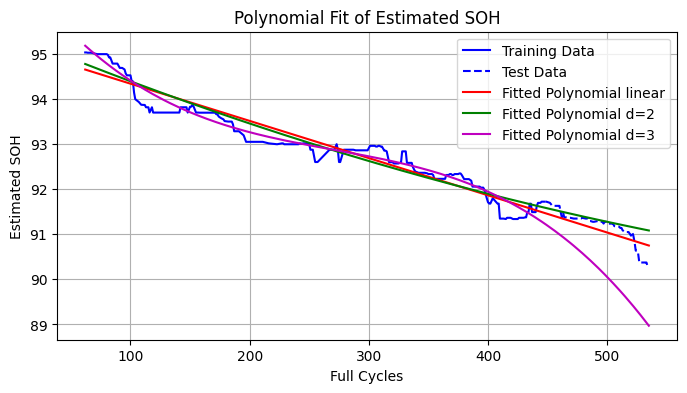

In [144]:
#### Make the polynomial model
# Define the degree of the polynomial (e.g., 2 for a quadratic fit)
d1 = 1;
d2 = 2;
d3 = 3;  # Adjust as needed
# Fit the polynomial using polyfit
coefficients = np.polyfit(X_train, y_train, d1)
coefficients2 = np.polyfit(X_train, y_train, d2)
coefficients3 = np.polyfit(X_train, y_train, d3)

# Create a polynomial function using the coefficients
polynomial = np.poly1d(coefficients)
polynomial2 = np.poly1d(coefficients2)
polynomial3 = np.poly1d(coefficients3)

# Generate fitted values for plotting or further analysis
fitted_values = polynomial(x_values)
fitted_values2 = polynomial2(x_values)
fitted_values3 = polynomial3(x_values)

# Plot the original data and the fitted polynomial
plt.figure(figsize=(8, 4))
plt.plot(X_train, y_train, label='Training Data', color='b')
plt.plot(X_test,  y_test,  label='Test Data', color='b', linestyle='--')

plt.plot(x_values, fitted_values,  label='Fitted Polynomial linear' , color='r')
plt.plot(x_values, fitted_values2, label=f'Fitted Polynomial d={d2}', color='g')
plt.plot(x_values, fitted_values3, label=f'Fitted Polynomial d={d3}', color='m')
plt.xlabel('Full Cycles')
plt.ylabel('Estimated SOH')
plt.title('Polynomial Fit of Estimated SOH')
# Set the y-axis ticks to change by 1 point
#plt.yticks(np.arange(int(min(y_values)), int(max(y_values)) + 1, 1))
plt.grid(True)  # Optionally add a grid for better readability
#plt.ylim(bottom=96)

plt.legend()
plt.show()

Trend analysis

In [63]:
coefficients ## most are negative = negative trend

array([-2.22703516e-02,  9.86341345e+01])

In [64]:
# Last SOH
y_values.tail(2)

,Bat_Capacity
196,93.848133
197,93.848133


## Extrapolating the model into the future

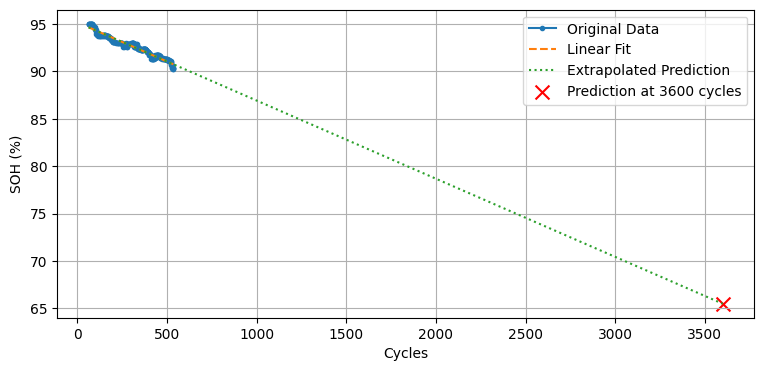

In [145]:
###  extrapolating the model for 3500 cycles
# Extrapolate to 3500 cycles
years_ahead = 10
cycle_max = 360 * years_ahead  # The cycle number to extrapolate to
predicted_soh_max = polynomial(cycle_max)

# Create a range of cycle numbers for plotting
cycle_range = np.linspace(min(x_values), cycle_max, 1100)  # Extends
# Calculate predicted SOH values for the extended cycle range
predicted_soh_range = polynomial(cycle_range)

# Plot the original data, fitted curve, and extrapolated prediction
plt.figure(figsize=(9, 4))  # Adjust figure size as needed

plt.plot(x_values, y_values, label='Original Data', marker='.', linestyle='-')
plt.plot(x_values, fitted_values, label='Linear Fit', linestyle='--')
plt.plot(cycle_range, predicted_soh_range, label='Extrapolated Prediction', linestyle=':')

plt.scatter(cycle_max, predicted_soh_max, color='red', marker='x', s=100, label=f'Prediction at {cycle_max} cycles')  # Highlight the extrapolated point

#plt.xlim(0, 400 * years_ahead)  # Set the x-axis limit
#plt.ylim((99-years_ahead*2.5), 100)  # Set the y-axis limit

plt.xlabel('Cycles')
plt.ylabel('SOH (%)')
#plt.title(f'Polynomial Fit and Extrapolation of Estimated SOH for {years_ahead} years')
plt.legend()
plt.grid(True)
plt.show()

In [86]:
predicted_soh_max

np.float64(28.652644047603175)

In [ ]:
len(predicted_soh_range)

1100

In [66]:
# Data taken from RESU battery website:
#https://www.cleanenergyreviews.info/blog/lg-resu-solar-battery-review

# 1. Generate synthetic data for demonstration
num_cycles = 1100  # For example, 1110 points from cycle 0 to 1100
cycles = np.linspace(0, 1100, num_cycles)

# Let's assume an initial capacity around 7800 Wh,
# decreasing gradually by ~500 Wh over 1100 cycles
# initial_capacity = 7800

initial_capacity = Bat_capacity_initial * 0.875
capacity_drop = 1400  # total drop from cycle 0 to 1100
slope = capacity_drop / 1100

# Create a linear fade plus some random noise
np.random.seed(42)  # for reproducible results
noise = np.random.normal(loc=0.0, scale=100.0, size=num_cycles)
capacity_data = initial_capacity - slope * cycles + noise

SOH_resu =  (capacity_data/initial_capacity)*100;

# Ensure SOH_resu does not exceed 100%
SOH_resu = np.clip(SOH_resu, None, 100)

'''
# 2. Create the plot
plt.figure(figsize=(8, 5))
plt.scatter(cycles, SOH_resu , color='red', s=8, alpha=0.8, marker='o')
plt.title("Benchmark  Full Charge Capacity per Cycle")
plt.xlabel("Cycle Count")
plt.ylabel("Full Charge Capacity (Wh)")
#plt.ylim(0000, 9000)  # adjust as needed to fit the data range
plt.xlim(0, 1100)     # from cycle 0 to 1100
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
'''

print(f"Last Capacity Value: {capacity_data[-1]}")
percent_drop = (capacity_data[-1])/capacity_data[0]
print(f"Percent Capacity Drop: {percent_drop:.2%}")  # :.2% formats as percentage with 2 decimal places


Last Capacity Value: 7209.6488475897995
Percent Capacity Drop: 83.59%


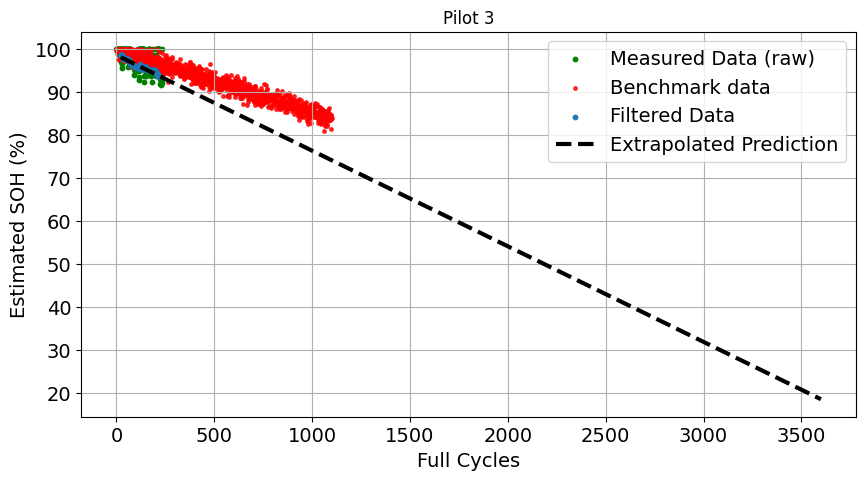

In [67]:

plt.figure(figsize=(10, 5))
plt.scatter(estimated_soh['Cycle'],estimated_soh['Bat_Capacity'], label='Measured Data (raw)', color='green', s=10)

plt.scatter(cycles, SOH_resu , color='red', s=6, alpha=0.8, marker='o', label='Benchmark data' )
plt.scatter(x_values, y_values, label='Filtered Data', marker='o', s=10)
#plt.plot(x_values, fitted_values, label='Fitted Polynomial', linestyle='--', linewidth =3)
plt.plot(cycle_range, predicted_soh_range, label='Extrapolated Prediction', linestyle='--',color='black', linewidth =3)

#plt.scatter(cycle_max, predicted_soh_max, color='red', marker='x', s=100, label=f'Prediction at {cycle_max} cycles')  # Highlight the extrapolated point

plt.title(f'Pilot 3')
plt.xlabel('Full Cycles', fontsize=14)
#plt.ylim([96,100])
plt.ylabel('Estimated SOH (%)', fontsize=14)
#plt.title('Benchmark vs Estimated SOH', fontsize=14)
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

def evaluate_model(y_test, y_pred):
  mae = mean_absolute_error(y_test, y_pred)
  mape = mean_absolute_percentage_error(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  nrmse = rmse / np.max(y_test)

  print(f'mae: {round(mae,3)}')
  print(f'mape: {100*round(mape,3)} %')
  print(f'rmse: {round(rmse,3)}')
  print(f'nrmse: {100*round(nrmse,3)} %')

# Example usage:
print('Load model evaluation')
evaluate_model(SOH_resu, predicted_soh_range)




Load model evaluation
mae: 1.048
mape: 1.0999999999999999 %
rmse: 1.055
nrmse: 1.0999999999999999 %


## Check trend?

In [ ]:
#!pip install pymannkendall

In [ ]:
'''
import pymannkendall as mk
# Perform Mann-Kendall Trend Test
#This non-parametric test can identify whether a trend exists in the time series data.
#It tests the null hypothesis of no trend versus the alternative hypothesis of a trend.
#A significant p-value (typically < 0.05) would indicate a statistically significant trend.
result = mk.original_test(estimated_soh_ma)

# Print the result
print("Mann-Kendall Trend Test Result:")
print(f"Trend: {result.trend}")
print(f"p-value: {result.p}")
print(f"Tau: {result.Tau}")
print(f"Slope: {result.slope}")

# Interpretation:
if result.p < 0.05:
    print("The trend is statistically significant.")
else:
    print("The trend is not statistically significant.")
'''


'\nimport pymannkendall as mk\n# Perform Mann-Kendall Trend Test\n#This non-parametric test can identify whether a trend exists in the time series data.\n#It tests the null hypothesis of no trend versus the alternative hypothesis of a trend.\n#A significant p-value (typically < 0.05) would indicate a statistically significant trend.\nresult = mk.original_test(estimated_soh_ma)\n\n# Print the result\nprint("Mann-Kendall Trend Test Result:")\nprint(f"Trend: {result.trend}")\nprint(f"p-value: {result.p}")\nprint(f"Tau: {result.Tau}")\nprint(f"Slope: {result.slope}")\n\n# Interpretation:\nif result.p < 0.05:\n    print("The trend is statistically significant.")\nelse:\n    print("The trend is not statistically significant.")\n'

# ML model fitting

In [ ]:
|#df.head()
#filtered_df.info()
#filtered_df.head()
grouped_filtered_df.head(4)

,Timestamp,Charge_W,Discharge_W,SOC_%,Net Power W,Time_diff_hours,Cycle,Energy_Wh,Bat_Capacity,Estimated_SOC
471,2018-02-18 14:45:00,857,0,99.50,857,0.25,0,214.25,9248.05250,94.367883
472,2018-02-18 15:00:00,267,0,100.00,267,0.25,0,66.75,9248.05250,94.367883
473,2018-02-18 15:15:00,30,0,100.00,30,0.25,0,7.50,9248.05250,94.367883
474,2018-02-18 15:30:00,234,0,100.00,234,0.25,0,58.50,9248.05250,94.367883
1146,2018-02-25 15:30:00,125,0,100.00,125,0.25,6,31.25,9199.85075,93.876028
...,...,...,...,...,...,...,...,...,...,...
53854,2019-08-28 16:30:00,497,134,99.33,363,0.25,576,90.75,8680.37075,88.575212
54043,2019-08-30 15:45:00,673,0,99.67,673,0.25,578,168.25,8584.71650,87.599148
54044,2019-08-30 16:00:00,248,0,100.00,248,0.25,578,62.00,8584.71650,87.599148
54045,2019-08-30 16:15:00,371,0,100.00,371,0.25,578,92.75,8584.71650,87.599148


In [ ]:
def create_lag_features(df, target_col):
    # Create lag features
    df['lag1'] = df[target_col].shift(1)  # Lag by 1 cycle
    df['lag2'] = df[target_col].shift(2)  # Lag by 2 cycles
    df['lag10'] = df[target_col].shift(10)  # Lag by 10
    # Calculate rolling average
    window_size = int(len(df) / 10)
    df['rolling_avg'] = df[target_col].rolling(window=window_size).mean()

    # Handle missing values
    df.bfill(inplace=True)  # Backfill
    return df

input_df = create_lag_features(estimated_soh_filtered,'Bat_Capacity')
input_df.info()
input_df.tail(5)

<class 'pandas.core.frame.DataFrame'>
Index: 161 entries, 20 to 180
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Cycle         161 non-null    int64  
 1   Bat_Capacity  161 non-null    float64
 2   lag1          161 non-null    float64
 3   lag2          161 non-null    float64
 4   lag10         161 non-null    float64
 5   rolling_avg   161 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 8.8 KB


,Cycle,Bat_Capacity,lag1,lag2,lag10,rolling_avg
176,511,90.984413,90.984413,90.984413,90.899759,90.968663
177,513,90.984413,90.984413,90.984413,90.899759,90.969278
178,514,91.023130,90.984413,90.984413,90.984413,90.972314
179,515,91.035599,91.023130,90.984413,91.023130,90.976128
180,517,91.023130,91.035599,91.023130,91.023130,90.983839


In [ ]:
# SOH model inputs: Add previous SOH values,
input_cols = [ 'Cycle', 'lag1',	'lag2',	'lag10',	'rolling_avg' ]
output_cols =[ 'Bat_Capacity']
inputs = input_df[input_cols]
output = input_df[output_cols]

split_point = int((len(input_df) * 0.80))
X_train, X_test = inputs[:split_point], inputs[split_point:]
y_train, y_test = output[:split_point], output[split_point:]

In [ ]:
from xgboost import XGBRegressor

model2 = XGBRegressor(max_depth=25, objective = 'reg:squarederror',
                      n_estimators = 40, random_state=42, n_jobs=-1)
#model2 = XGBRegressor(colsample_bytree=0.827, learning_rate=0.019, n_estimators=317, n_jobs=-1, random_state=42)

model2.fit(X_train, y_train, eval_set = [(X_train, y_train),(X_test, y_test)], verbose=True)
y_pred = model2.predict(X_test)


[0]	validation_0-rmse:0.75670	validation_1-rmse:1.30114
[1]	validation_0-rmse:0.54558	validation_1-rmse:0.99790
[2]	validation_0-rmse:0.39488	validation_1-rmse:0.75286
[3]	validation_0-rmse:0.28674	validation_1-rmse:0.59146
[4]	validation_0-rmse:0.20923	validation_1-rmse:0.45259
[5]	validation_0-rmse:0.15375	validation_1-rmse:0.35104
[6]	validation_0-rmse:0.11382	validation_1-rmse:0.27519
[7]	validation_0-rmse:0.08550	validation_1-rmse:0.22078
[8]	validation_0-rmse:0.06518	validation_1-rmse:0.17991
[9]	validation_0-rmse:0.05075	validation_1-rmse:0.14900
[10]	validation_0-rmse:0.03985	validation_1-rmse:0.14052
[11]	validation_0-rmse:0.03178	validation_1-rmse:0.13391
[12]	validation_0-rmse:0.02588	validation_1-rmse:0.12873
[13]	validation_0-rmse:0.02110	validation_1-rmse:0.12471
[14]	validation_0-rmse:0.01729	validation_1-rmse:0.11982
[15]	validation_0-rmse:0.01425	validation_1-rmse:0.11618
[16]	validation_0-rmse:0.01179	validation_1-rmse:0.11347
[17]	validation_0-rmse:0.00979	validation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
nrmse = rmse / np.max(y_test);

print(f'mae: {round(mae,2)}')
print(f'mape: {100*round(mape,4)} %')
print(f'rmse: {round(rmse,2)}')
print(f'nrmse: {100*round(nrmse,4)} %')

mae: 0.1
mape: 0.11 %
rmse: 0.11
nrmse: 0.12 %


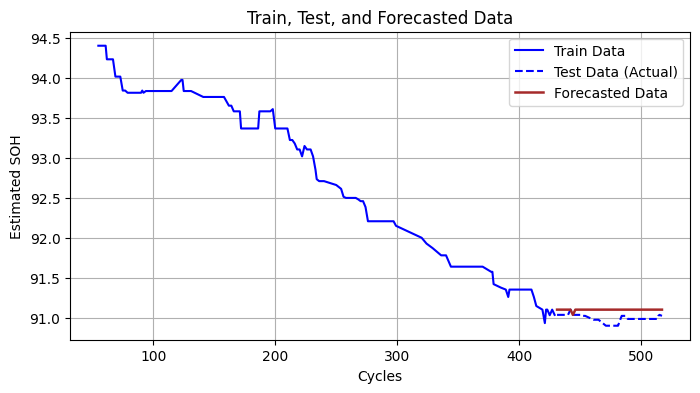

In [ ]:
# Plot train data
plt.figure(figsize=(8, 4))
plt.plot(X_train['Cycle'], y_train, label='Train Data', color='blue')

# Plot test data
plt.plot(X_test['Cycle'], y_test, label='Test Data (Actual)', color='blue', linestyle = '--')
# Plot forecasted data
plt.plot(X_test['Cycle'], y_pred, label='Forecasted Data', color='brown', linewidth=1.8)

# Customize the plot
plt.title('Train, Test, and Forecasted Data')
plt.xlabel('Cycles')
plt.ylabel('Estimated SOH')
plt.legend()
plt.grid(True)
#plt.tight_layout()

# Show the plot
plt.show()

# Linear SOH models (empirical)

In [ ]:
def estimate_battery_soh(cycles, charge_rates, discharge_rates, soc_values, capacity, dod, efficiency):
    # Convert inputs to numpy arrays for vectorized operations
    cycles = np.array(cycles)
    charge_rates = np.array(charge_rates)
    discharge_rates = np.array(discharge_rates)
    soc_values = np.array(soc_values)

    # Calculate stress factors
    cycle_stress = calculate_cycle_stress(cycles)
    rate_stress = calculate_rate_stress(charge_rates, discharge_rates)
    soc_stress = calculate_soc_stress(soc_values)
    dod_stress = calculate_dod_stress(dod)
    efficiency_stress = calculate_efficiency_stress(efficiency)

    # Combine stress factors
    total_stress = (cycle_stress + rate_stress + soc_stress + dod_stress + efficiency_stress) / 5

    # Estimate SOH
    initial_soh = 100
    degradation_rate = 0.010  ### This value should be calibrated based on historical data
    estimated_soh = initial_soh - degradation_rate * total_stress * cycles[-1]

    # Ensure the result is a scalar, not an array
    #if isinstance(estimated_soh, np.ndarray):
    #    estimated_soh = estimated_soh.item()

    return max(0, min(100, estimated_soh))

def calculate_cycle_stress(cycles):
    # Assuming higher number of cycles leads to more stress
    return cycles[-1] / np.max(cycles) if len(cycles) > 0 else 0

def calculate_rate_stress(charge_rates, discharge_rates):
    # Combine charge and discharge rates, assuming higher rates lead to more stress
    combined_rates = np.concatenate((charge_rates, discharge_rates))
    return np.mean(combined_rates) / np.max(combined_rates) if len(combined_rates) > 0 else 0

def calculate_soc_stress(soc_values):
    # Assume stress is higher at extreme SOC values
    return np.mean(np.abs(soc_values - 50) / 50) if len(soc_values) > 0 else 0

def calculate_dod_stress(dod):
    # Higher DoD leads to more stress
    return dod

def calculate_efficiency_stress(efficiency):
    # Lower efficiency indicates more stress
    return 1 - efficiency



In [ ]:
# Example usage
#cycles = np.arange(1, 366*2)  # 365 days
cycles = np.arange(1, max(df['Cycle']));

#charge_rates = np.random.uniform(0.1, 1, 8760)  # Hourly for a year
charge_rates = df['Charge_W']  # Hourly for a year
#discharge_rates = np.random.uniform(0.1, 1, 8760)
discharge_rates = df['Discharge_W']
#soc_values = np.random.uniform(20, 80, 8760)
soc_values = df['SOC_%'] # In percetage %

capacity = Bat_capacity_initial  # Wh
dod = 0.9
efficiency = 0.96

estimated_soh = estimate_battery_soh(cycles, charge_rates, discharge_rates, soc_values, capacity, dod, efficiency)
print(f"Estimated SOH: {estimated_soh:.2f}%")

Estimated SOH: 97.27%


In [ ]:
'''
The same model, but calculating daily SOH, to plot daily SOH over a year.
'''

def estimate_daily_soh(cycles, charge_rates, discharge_rates, soc_values, capacity, dod, efficiency, degradation_rate):
    daily_soh = []
    initial_soh = 100  # initial SOH 100%

    #degradation_rate = 0.010  # This value should be calibrated based on historical data

    for day in range(1, len(cycles) + 1):
        # Calculate stress factors up to this day
        cycle_stress = calculate_cycle_stress(cycles[:day])
        rate_stress = calculate_rate_stress(charge_rates[:day*24], discharge_rates[:day*24])
        soc_stress = calculate_soc_stress(soc_values[:day*24])
        dod_stress = calculate_dod_stress(dod)
        efficiency_stress = calculate_efficiency_stress(efficiency)

        # Combine stress factors
        total_stress = (cycle_stress + rate_stress + soc_stress + dod_stress + efficiency_stress) / 5

        # increasing degr. rate
        degradation_rate = degradation_rate * (1.000001 ** (cycles[-1] // 365))

        # Estimate SOH for this day
        estimated_soh = initial_soh - degradation_rate * total_stress * day
        daily_soh.append(max(0, min(100, estimated_soh)))

    #return daily_soh
    return daily_soh , total_stress

def calculate_cycle_stress(cycles):
    # Assuming higher number of cycles leads to more stress
    return cycles[-1] / np.max(cycles)
    #return cycles.iloc[-1] / np.max(cycles)

def calculate_rate_stress(charge_rates, discharge_rates):
    # Combine charge and discharge rates, assuming higher rates lead to more stress
    combined_rates = np.concatenate((charge_rates, discharge_rates))
    return np.mean(combined_rates) / np.max(combined_rates) if len(combined_rates) > 0 else 0

def calculate_soc_stress(soc_values):
    # Assume stress is higher at extreme SOC values
    return np.mean(np.abs(soc_values - 50) / 50) if len(soc_values) > 0 else 0

def calculate_dod_stress(dod):
    # Higher DoD leads to more stress
    return dod

def calculate_efficiency_stress(efficiency):
    # Lower efficiency indicates more stress
    return 1 - efficiency



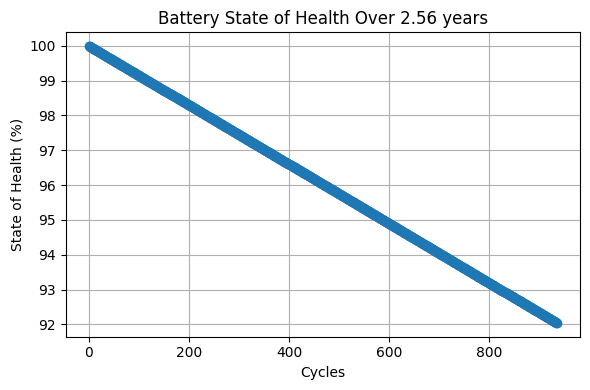

Final estimated SOH after 2.56 years: 92.05%


In [ ]:
# Example usage
#days = 365*10      # take from the datgaset
#cycles = np.arange(1, days+1)  # 365 days ### Get the cycles from the dataser

cycles = np.arange(1, 5*max(df['Cycle']));
days = len(cycles)

#charge_rates = np.random.uniform(0.1, 1, days*24)  # Hourly for a year
charge_rates = df['Charge_W']/ np.max(df['Charge_W'])  # from the results of the simulation (once a day)
#discharge_rates = np.random.uniform(0.1, 1,  days*24)
discharge_rates = df['Discharge_W'] / np.max(df['Discharge_W'])
#soc_values = np.random.uniform(20, 80,  days*24)
soc_values = (df['SOC_%']/np.max(df['SOC_%']) )*100  # In percetage %

capacity = Bat_capacity_initial  # Wh
dod = 0.9
efficiency = 0.96
degradation_rate = 0.015 # 1.5% per year

# Calculate daily SOH
daily_soh , total_stress = estimate_daily_soh(cycles, charge_rates, discharge_rates, soc_values, capacity, dod, efficiency, degradation_rate)

# Plot the results
plt.figure(figsize=(6, 4))
plt.plot(cycles, daily_soh, marker='o')
plt.title(f'Battery State of Health Over {round(days/365,2)} years')
plt.xlabel('Cycles')
plt.ylabel('State of Health (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final SOH
print(f"Final estimated SOH after {round(days/365,2)} years: {daily_soh[-1]:.2f}%")